In [1]:
from detection.segmentation.inference_two_stage import TwoStageInference

c:\Users\USER\anaconda3\envs\2d_ui\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\USER\anaconda3\envs\2d_ui\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
c:\Users\USER\anaconda3\envs\2d_ui\lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
c:\Users\USER\anaconda3\envs\2d_ui\lib\site-packages\mobile_sam\modeling\tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.

In [2]:
segmentation_model = TwoStageInference()

Loading model on cpu...
✓ Model loaded successfully



In [3]:
res = segmentation_model.predict(r"\\172.16.0.10\d-pai\01_data\2d_conveyor\capture_20260128_132046_987_0001.jpg")

Stage 1: Running detector...
Detected 86 instances
Stage 2: Running MobileSAM with detected boxes...


In [8]:
%pip install shapely

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 47.1 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [9]:
from shapely.geometry import Polygon, Point, LineString, MultiPolygon

In [11]:
polygons = []
for i, poly in enumerate(res['contours']):
    polygons.append({
        "polygon": Polygon(poly),
        "label": res["labels"][i]
    })

In [13]:
%pip install matplotlib

  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp310-cp310-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp310-cp310-win_amd64.whl (1.6 MB)
Using cached kiwisolver-1.4.9-cp310-cp310-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- --

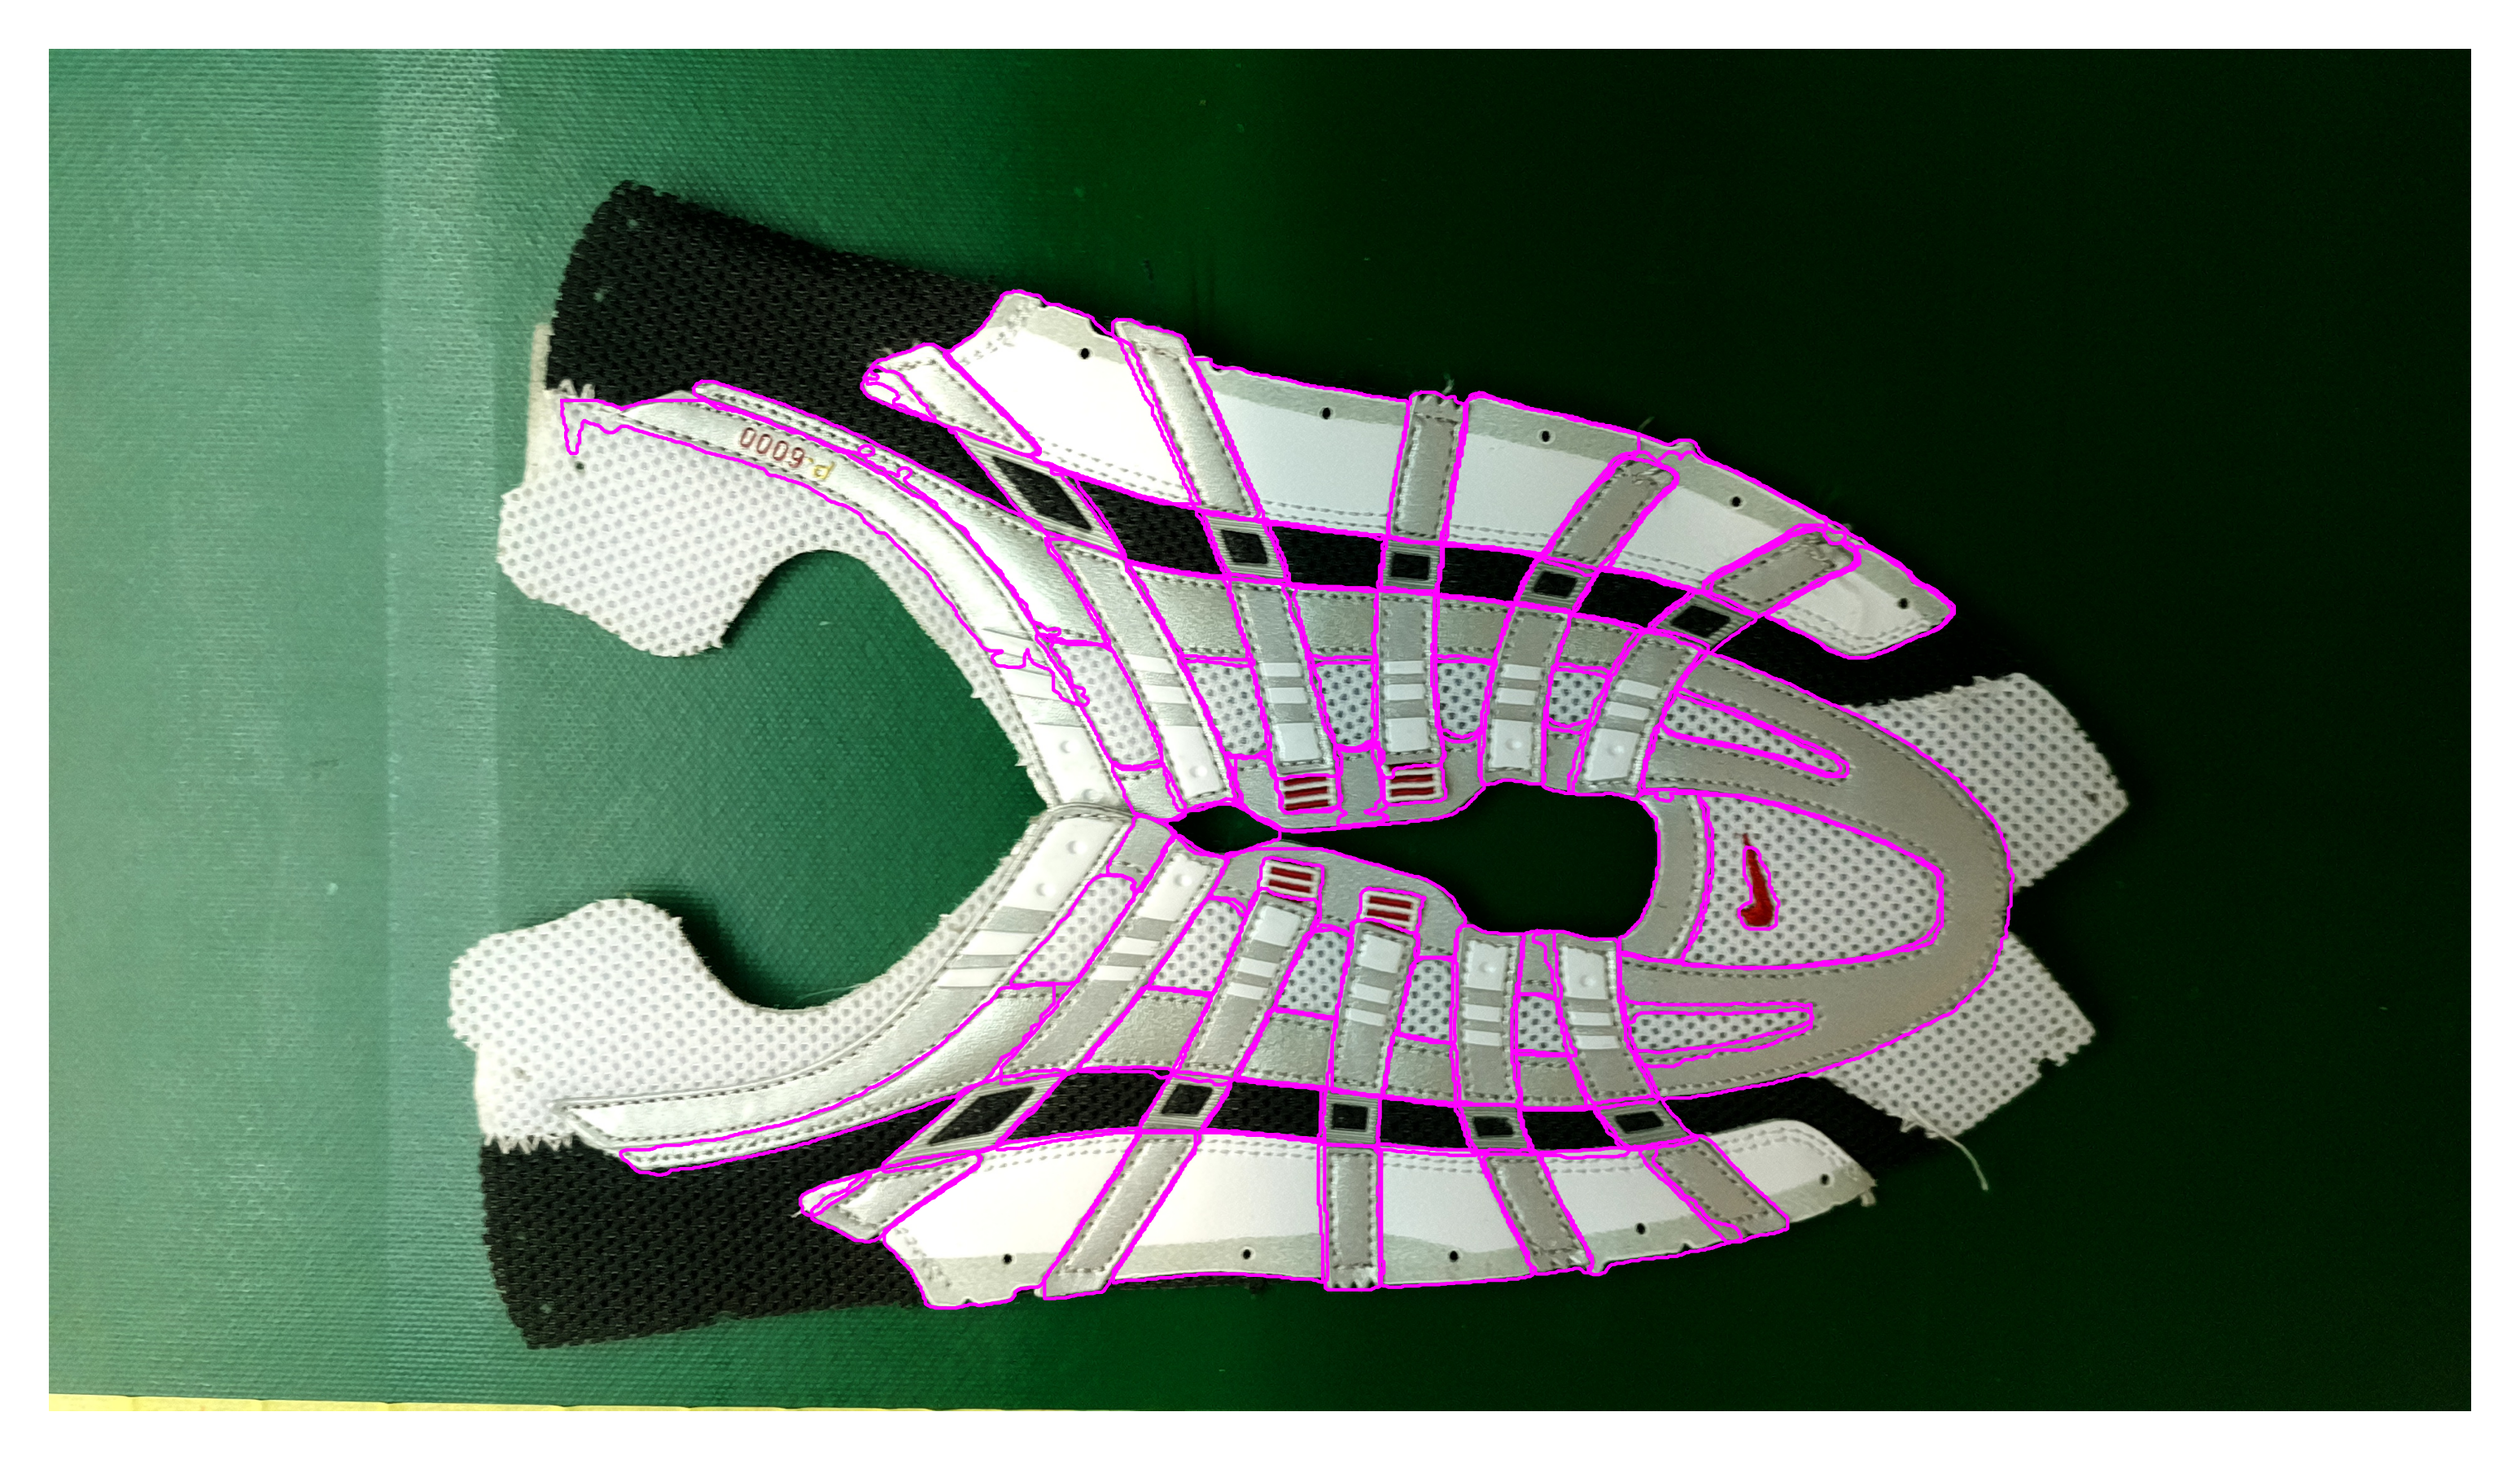

In [22]:
import matplotlib.pyplot as plt
import cv2

def load_image(image_path):
    """Loads the image from the specified path."""
    return cv2.imread(image_path)

plt.figure(dpi=600)
plt.imshow(cv2.cvtColor(load_image(r"\\172.16.0.10\d-pai\01_data\2d_conveyor\capture_20260128_132046_987_0001.jpg"), cv2.COLOR_BGR2RGB))

for item in polygons:
    x, y = item["polygon"].exterior.xy
    plt.plot(x, y, c='magenta', linewidth=0.5)

plt.axis('off')
plt.show()

In [1]:
from detection.point_detection.inference import PointDetInference

c:\Users\USER\anaconda3\envs\2d_ui\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = PointDetInference()
res = model.predict(r"\\172.16.0.10\d-pai\01_data\2d_conveyor\capture_20260128_132046_987_0001.jpg")

Slicing: 100%|██████████| 14/14 [00:07<00:00,  1.84it/s]


In [ ]:
res['points']

In [3]:
import cv2
import matplotlib.pyplot as plt

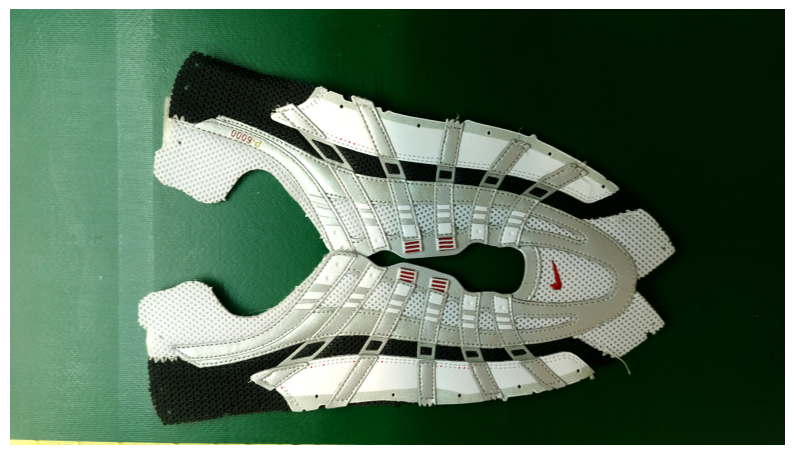

In [6]:
img = cv2.imread(
    r"\\172.16.0.10\d-pai\01_data\2d_conveyor\capture_20260128_132046_987_0001.jpg"
)
base_img = img.copy()

for p in res['overlap']:
    x, y = map(int, p)
    cv2.circle(base_img, (x, y), 2, (0, 0, 255), 2)

img_rgb = cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()